In [1]:
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.stats.sandwich_covariance import cov_hac
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from arch import arch_model
from arch.univariate import ARX
from scipy.stats import norm

### Import data

In [3]:
path = os.path.abspath('E:/RA/Geert/task1.py')
dir_path = os.path.dirname(path)
os.chdir(dir_path)
excel_file = pd.ExcelFile('Aggregate_CPI_inflation_20230513.xls')
sheet_quarter = excel_file.sheet_names[0]
sheet_month = excel_file.sheet_names[1]
#quarterly and monthly aggregate CPI data (deseasonalized). The full sample is 1947-2022
data_quarter = excel_file.parse(sheet_quarter, skiprows=2)
data_month = excel_file.parse(sheet_month, skiprows=2)
data_quarter.index = pd.to_datetime(data_quarter['Year'].astype(str) + '-Q' + data_quarter['Quarter'].astype(str))
data_month.index = pd.to_datetime(data_month[['Year', 'Month']].assign(day=1))
data_quarter.columns = ['Year', 'Quarter', 'Price index', 'Inflation', 'Forecasted inflation', 'Inflation shock']
data_month.columns = ['Year', 'Month', 'Price index', 'Inflation', 'Forecasted inflation', 'Inflation shock']
sample_data = data_quarter[data_quarter['Year']>1969]

In [5]:
sample_data['Inflation_lag_1'] =  sample_data['Inflation'].shift(1)
sample_data['Inflation_lag_2'] =  sample_data['Inflation'].shift(2)
sample_data['Forecasted_inflation_lag_1'] =  sample_data['Forecasted inflation'].shift(1)
sample_data = sample_data.dropna()

# Summary Statistics

In [15]:
sample_data.iloc[:,2:6].describe()

,Price index,Inflation,Forecasted inflation,Inflation shock
count,208.000000,208.000000,208.000000,208.000000
mean,157.355933,0.977915,0.834174,0.143740
std,69.622562,0.868335,0.505075,0.668553
min,40.000000,-3.416988,0.104789,-4.011699
25%,102.525000,0.521632,0.472913,-0.171325
50%,159.450000,0.778000,0.619098,0.093864
75%,217.380500,1.265450,1.017569,0.442225
max,298.990000,4.161248,2.456609,2.172944


In [52]:
print("Autocorrelation of Quarterly Inflation Series")
for lag_ in range(1, 4):
    autocorrelation = sample_data['Inflation'].autocorr(lag=lag_)
    print(f"Autocorrelation at lag {lag_}: {autocorrelation}")

Autocorrelation of Quarterly Inflation Series
Autocorrelation at lag 1: 0.5990661110434156
Autocorrelation at lag 2: 0.5338504692929864
Autocorrelation at lag 3: 0.5747833583359523


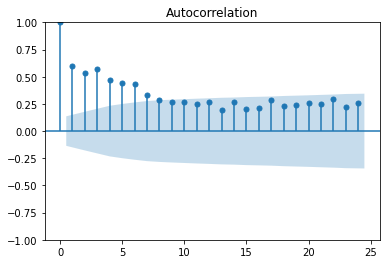

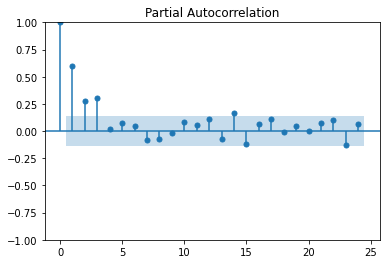

In [54]:
plot_acf(sample_data['Inflation'])
plot_pacf(sample_data['Inflation'])
plt.show()

## Model Selection

 ### GARCH model specification

GARCH(p,q) model specification:
$$
 \sigma_{t}^{2}=\omega +\sum_{i=1}^{p}\alpha_{i} \epsilon_{t-i}^2
         +\sum_{k=1}^{q}\beta_{k}\sigma_{t-k}^{2} 
$$

EGARCH(p,q) model specification:
$$
 \ln\sigma_{t}^{2}=\omega +\sum_{i=1}^{p}[ \alpha_{i}  \left(\left|e_{t-i}\right|-\sqrt{2/\pi}\right)
        +\gamma_{i} e_{t-i}] +\sum_{k=1}^{q}\beta_{k}\ln\sigma_{t-k}^{2} 
$$
where :
$e_{t}=\epsilon_{t}/\sigma_{t}$

GJR-GARCH model specification:
$$
\sigma_{t}^{2}=\omega  + \sum_{i=1}^{p}\left(\alpha_{i}\epsilon_{t-i}^{2}
        +\gamma_{i}\epsilon_{t-i}^{2}
        I\left[\epsilon_{t-i}<0\right]\right)+\sum_{k=1}^{q}\beta_{k}\sigma_{t-k}^{2}
$$


ARX model specification
$$
y_t = \mu + \sum_{i=1}^p \phi_{L_{i}} y_{t-L_{i}} + \gamma' x_t   + \epsilon_t
$$

When estimating standard errors of Garch coefficients, this package provides three choices:
1. Classic standard errors (also known as White's or QMLE standard errors)
2. Robust standard errors (also known as Bollerslev-Wooldridge robust covariance estimator, which provides robustness to misspecification)

**Robust Standard Errors**
1. Calculate Hessian Matrix and Score Function using numerical method
2. Cov(params) = Inv(Hessian) $\cdot$ Cov(Score)$\cdot$ Inv(Hessian) / T

T is the number of observations

### Mean model and Variance model are jointly estimated. 

In [10]:
def GarchFamilyResults(Y,X=None,mean='Zero',lags=None,cov = 'robust'):
    options = {'maxiter': 1000}
    garch11 = arch_model(y=Y,x=X, mean=mean, vol='GARCH',p=1, q=1,dist='normal',lags=lags).fit(disp='off',cov_type=cov,options=options)
    garch21 = arch_model(y=Y,x=X, mean=mean, vol='GARCH',p=2, q=1,dist='normal',lags=lags).fit(disp='off',cov_type=cov,options=options)
    garch12 = arch_model(y=Y,x=X, mean=mean, vol='GARCH',p=1, q=2,dist='normal',lags=lags).fit(disp='off',cov_type=cov,options=options)
    garch22 = arch_model(y=Y,x=X, mean=mean, vol='GARCH',p=2, q=2,dist='normal',lags=lags).fit(disp='off',cov_type=cov,options=options)
    print('\nGARCH(p,q) model')
    print('\t \t AIC: \t \t \t BIC',
          '\nGARCH(1,1): ',garch11.aic,'\t',garch11.bic,
          '\nGARCH(2,1): ',garch21.aic,'\t',garch21.bic,
          '\nGARCH(1,2): ',garch12.aic,'\t',garch12.bic,
          '\nGARCH(2,2): ',garch22.aic,'\t',garch22.bic,)
    
    sparch11 = arch_model(y=Y,x=X, mean=mean, vol='GARCH',p=1, q=1,lags=lags)
    sparch11.distribution = MixNormal()
    sparch11=sparch11.fit(disp='off',cov_type=cov,options=options)
    sparch21 = arch_model(y=Y,x=X, mean=mean, vol='GARCH',p=2, q=1,lags=lags)
    sparch21.distribution = MixNormal()
    sparch21=sparch21.fit(disp='off',cov_type=cov,options=options   )            
    sparch12 = arch_model(y=Y,x=X, mean=mean, vol='GARCH',p=1, q=2,lags=lags)
    sparch12.distribution = MixNormal()
    sparch12=sparch12.fit(disp='off',cov_type=cov,options=options   )
    sparch22 = arch_model(y=Y,x=X, mean=mean, vol='GARCH',p=2, q=2,lags=lags)
    sparch22.distribution = MixNormal()
    sparch22=sparch22.fit(disp='off',cov_type=cov,options=options   )
    print('\nSPARCH(p,q) model')
    print('\t \t AIC: \t \t \t BIC',
          '\nSPARCH(2,1,1): ',sparch11.aic,'\t',sparch11.bic,
          '\nSPARCH(2,2,1): ',sparch21.aic,'\t',sparch21.bic,
          '\nSPARCH(2,1,2): ',sparch12.aic,'\t',sparch12.bic,
          '\nSPARCH(2,2,2): ',sparch22.aic,'\t',sparch22.bic,)

    egarch11 = arch_model(y=Y,x=X, mean=mean, vol='EGARCH',p=1, o=1, q=1,dist='normal',lags=lags).fit(disp='off',cov_type=cov,options=options)
    egarch12 = arch_model(y=Y,x=X, mean=mean, vol='EGARCH',p=1, o=1, q=2,dist='normal',lags=lags).fit(disp='off',cov_type=cov,options=options)
    egarch21 = arch_model(y=Y,x=X, mean=mean, vol='EGARCH',p=2, o=2, q=1,dist='normal',lags=lags).fit(disp='off',cov_type=cov,options=options)
    egarch22 = arch_model(y=Y,x=X, mean=mean, vol='EGARCH',p=2, o=2, q=2,dist='normal',lags=lags).fit(disp='off',cov_type=cov,options=options)
    print('\nEGARCH(p,q) model')
    print('\t \t AIC: \t \t \t BIC',
          '\nEGARCH(1,1): ',egarch11.aic,'\t',egarch11.bic,
          '\nEGARCH(1,2): ',egarch12.aic,'\t',egarch12.bic,
          '\nEGARCH(2,1): ',egarch21.aic,'\t',egarch21.bic,
          '\nEGARCH(2,2): ',egarch22.aic,'\t',egarch22.bic,  )

    gjr_garch11 = arch_model(y=Y,x=X, mean=mean, vol='GARCH',p=1, o=1,q=1,dist='normal',lags=lags).fit(disp='off',cov_type=cov,options=options)
    gjr_garch12 = arch_model(y=Y,x=X, mean=mean, vol='GARCH',p=1, o=1,q=2,dist='normal',lags=lags).fit(disp='off',cov_type=cov,options=options)
    gjr_garch21 = arch_model(y=Y,x=X, mean=mean, vol='GARCH',p=2, o=2,q=1,dist='normal',lags=lags).fit(disp='off',cov_type=cov,options=options)
    gjr_garch22 = arch_model(y=Y,x=X, mean=mean, vol='GARCH',p=2, o=2,q=2,dist='normal',lags=lags).fit(disp='off',cov_type=cov,options=options)
    print('\nGJR-GARCH(p,q) model')
    print('\t \t AIC: \t \t \t BIC',
          '\nGJR-GARCH(1,1): ',gjr_garch11.aic,'\t',gjr_garch11.bic,
          '\nGJR-GARCH(1,2): ',gjr_garch12.aic,'\t',gjr_garch12.bic,
         '\nGJR-GARCH(2,1): ',gjr_garch21.aic,'\t',gjr_garch21.bic,
          '\nGJR-GARCH(2,2): ',gjr_garch22.aic,'\t',gjr_garch22.bic,)
    


### MLE Estimation

**Jointly Estimate Parameters of Mean and Variance Model**

This package simultaneously estimates mean and variance parameters by minimizing Log Likelihood, which is calculated by 
Iteration:
1. Compute residuals $\epsilon_t$ of mean model
2. Compute conditional variance $h_t$ using VolatilityModel
3. Compute likelihood function by
$$            
\ln L =\sum_{t=1}^T -\frac{1}{2}\left(\ln2\pi+\ln h_t +\frac{\epsilon^{2}_t}{h_t}\right)
$$
where $\epsilon_t$ is residual and $h_t$ is conditional variance at time t, Using scipy.optimizer  and SLSQP kernal.

Source from arch package arch/univariate/base.py line 439

$$            
L =\prod_{t=1}^T \frac{1}{ \sqrt{2\pi h_t} } \exp \{ - \frac{\epsilon_t^2}{2h_t} \}
$$

and
$$            
\ln L =\sum_{t=1}^T \left( -\frac{1}{2} \ln2\pi -\frac{1}{2} \ln h_t  -\frac{1}{2}\frac{\epsilon^{2}_t}{h_t}\right) 
$$

## Mean Model

$
\pi (t) =  fc(t-1) + \epsilon (t)
$

In [19]:
GarchFamilyResults(Y = sample_data['Inflation shock'],mean='Zero')


GARCH(p,q) model
	 	 AIC: 	 	 	 BIC 
GARCH(1,1):  388.0379574355466 	 398.05057167465054 
GARCH(2,1):  373.27265566284433 	 386.6228079816496 
GARCH(1,2):  390.03795745989464 	 403.3881097786999 
GARCH(2,2):  375.2726564583419 	 391.96034685684845


C:\Users\ADMINI~1\AppData\Local\Temp/ipykernel_9320/2676524339.py:105: RuntimeWarning: divide by zero encountered in log
  lls = log( 1/sqrt(sigma2) * ( p1/sqrt(2*pi*sigma_1**2) *  exp(-(resids/sqrt(sigma2)-u1)**2/(2*sigma_1**2))   +   p2/sqrt(2*pi*sigma_2**2) *  exp(-(resids/sqrt(sigma2)-u2)**2/(2*sigma_2**2))        )     )
D:\anaconda\lib\site-packages\arch\univariate\base.py:756: ConvergenceWarning: The optimizer returned code 8. The message is:
Positive directional derivative for linesearch
See scipy.optimize.fmin_slsqp for code meaning.

  warnings.warn(
C:\Users\ADMINI~1\AppData\Local\Temp/ipykernel_9320/2676524339.py:105: RuntimeWarning: divide by zero encountered in log
  lls = log( 1/sqrt(sigma2) * ( p1/sqrt(2*pi*sigma_1**2) *  exp(-(resids/sqrt(sigma2)-u1)**2/(2*sigma_1**2))   +   p2/sqrt(2*pi*sigma_2**2) *  exp(-(resids/sqrt(sigma2)-u2)**2/(2*sigma_2**2))        )     )
D:\anaconda\lib\site-packages\arch\univariate\base.py:756: ConvergenceWarning: The optimizer returned cod


SPARCH(p,q) model
	 	 AIC: 	 	 	 BIC 
SPARCH(2,1,1):  364.20221088981066 	 384.22743936801857 
SPARCH(2,2,1):  361.24089262345893 	 384.60365918136813 
SPARCH(2,1,2):  366.60731198664735 	 389.9700785445566 
SPARCH(2,2,2):  364.17266398709165 	 390.8729686247022

EGARCH(p,q) model
	 	 AIC: 	 	 	 BIC 
EGARCH(1,1):  370.12523196037864 	 383.4753842791839 
EGARCH(1,2):  372.12523173328174 	 388.81292213178835 
EGARCH(2,1):  362.4156155490822 	 382.4408440272901 
EGARCH(2,2):  364.41561566605105 	 387.7783822239603

GJR-GARCH(p,q) model
	 	 AIC: 	 	 	 BIC 
GJR-GARCH(1,1):  372.2648290743011 	 385.61498139310635 
GJR-GARCH(1,2):  374.2648300481526 	 390.95252044665915 
GJR-GARCH(2,1):  361.4027665224535 	 381.4279950006614 
GJR-GARCH(2,2):  363.402766364242 	 386.76553292215124


In [20]:
GarchFamilyResults(Y = sample_data['Inflation shock'],mean='Zero')


GARCH(p,q) model
	 	 AIC: 	 	 	 BIC 
GARCH(1,1):  388.0379574355466 	 398.05057167465054 
GARCH(2,1):  373.27265566284433 	 386.6228079816496 
GARCH(1,2):  390.03795745989464 	 403.3881097786999 
GARCH(2,2):  375.2726564583419 	 391.96034685684845


C:\Users\ADMINI~1\AppData\Local\Temp/ipykernel_9320/2676524339.py:105: RuntimeWarning: divide by zero encountered in log
  lls = log( 1/sqrt(sigma2) * ( p1/sqrt(2*pi*sigma_1**2) *  exp(-(resids/sqrt(sigma2)-u1)**2/(2*sigma_1**2))   +   p2/sqrt(2*pi*sigma_2**2) *  exp(-(resids/sqrt(sigma2)-u2)**2/(2*sigma_2**2))        )     )
D:\anaconda\lib\site-packages\arch\univariate\base.py:756: ConvergenceWarning: The optimizer returned code 8. The message is:
Positive directional derivative for linesearch
See scipy.optimize.fmin_slsqp for code meaning.

  warnings.warn(
C:\Users\ADMINI~1\AppData\Local\Temp/ipykernel_9320/2676524339.py:105: RuntimeWarning: divide by zero encountered in log
  lls = log( 1/sqrt(sigma2) * ( p1/sqrt(2*pi*sigma_1**2) *  exp(-(resids/sqrt(sigma2)-u1)**2/(2*sigma_1**2))   +   p2/sqrt(2*pi*sigma_2**2) *  exp(-(resids/sqrt(sigma2)-u2)**2/(2*sigma_2**2))        )     )
D:\anaconda\lib\site-packages\arch\univariate\base.py:756: ConvergenceWarning: The optimizer returned cod


SPARCH(p,q) model
	 	 AIC: 	 	 	 BIC 
SPARCH(2,1,1):  364.20221088981066 	 384.22743936801857 
SPARCH(2,2,1):  361.24089262345893 	 384.60365918136813 
SPARCH(2,1,2):  366.60731198664735 	 389.9700785445566 
SPARCH(2,2,2):  364.17266398709165 	 390.8729686247022

EGARCH(p,q) model
	 	 AIC: 	 	 	 BIC 
EGARCH(1,1):  370.12523196037864 	 383.4753842791839 
EGARCH(1,2):  372.12523173328174 	 388.81292213178835 
EGARCH(2,1):  362.4156155490822 	 382.4408440272901 
EGARCH(2,2):  364.41561566605105 	 387.7783822239603

GJR-GARCH(p,q) model
	 	 AIC: 	 	 	 BIC 
GJR-GARCH(1,1):  372.2648290743011 	 385.61498139310635 
GJR-GARCH(1,2):  374.2648300481526 	 390.95252044665915 
GJR-GARCH(2,1):  361.4027665224535 	 381.4279950006614 
GJR-GARCH(2,2):  363.402766364242 	 386.76553292215124


$
\pi (t) = c +\rho \pi (t-1)   + \phi fc(t-1) + \epsilon (t)
$

In [21]:
GarchFamilyResults(Y = sample_data['Inflation'],X=sample_data['Forecasted inflation'],mean='ARX',lags=[1])


GARCH(p,q) model
	 	 AIC: 	 	 	 BIC 
GARCH(1,1):  383.94209436861524 	 403.9384071282075 
GARCH(2,1):  373.93592296245623 	 397.26495451531383 
GARCH(1,2):  385.94209486185787 	 409.27112641471547 
GARCH(2,2):  375.9359219826037 	 402.5976723287267


C:\Users\ADMINI~1\AppData\Local\Temp/ipykernel_9320/2676524339.py:105: RuntimeWarning: divide by zero encountered in log
  lls = log( 1/sqrt(sigma2) * ( p1/sqrt(2*pi*sigma_1**2) *  exp(-(resids/sqrt(sigma2)-u1)**2/(2*sigma_1**2))   +   p2/sqrt(2*pi*sigma_2**2) *  exp(-(resids/sqrt(sigma2)-u2)**2/(2*sigma_2**2))        )     )
C:\Users\ADMINI~1\AppData\Local\Temp/ipykernel_9320/2676524339.py:103: RuntimeWarning: invalid value encountered in sqrt
  sigma_2 = sqrt(p1/(p1-1)*sigma_1**2 - p1/(p1-1)**2 * u1**2 + 1/(1-p1))
C:\Users\ADMINI~1\AppData\Local\Temp/ipykernel_9320/2676524339.py:102: RuntimeWarning: divide by zero encountered in double_scalars
  u2 = p1/(p1-1) *u1
C:\Users\ADMINI~1\AppData\Local\Temp/ipykernel_9320/2676524339.py:103: RuntimeWarning: divide by zero encountered in double_scalars
  sigma_2 = sqrt(p1/(p1-1)*sigma_1**2 - p1/(p1-1)**2 * u1**2 + 1/(1-p1))
C:\Users\ADMINI~1\AppData\Local\Temp/ipykernel_9320/2676524339.py:103: RuntimeWarning: invalid value encountered in doub


SPARCH(p,q) model
	 	 AIC: 	 	 	 BIC 
SPARCH(2,1,1):  371.0564540392915 	 401.05092317867985 
SPARCH(2,2,1):  367.999999839897 	 401.3271877725507 
SPARCH(2,1,2):  inf 	 inf 
SPARCH(2,2,2):  764.0677101715753 	 800.7276168974944

EGARCH(p,q) model
	 	 AIC: 	 	 	 BIC 
EGARCH(1,1):  368.24292344486616 	 391.57195499772376 
EGARCH(1,2):  370.2429288484053 	 396.9046791945283 
EGARCH(2,1):  361.14835679744726 	 391.1428259368356 
EGARCH(2,2):  363.14835798526036 	 396.475545917914

GJR-GARCH(p,q) model
	 	 AIC: 	 	 	 BIC 
GJR-GARCH(1,1):  368.96255838412196 	 392.29158993697956 
GJR-GARCH(1,2):  370.9625584063996 	 397.62430875252255 
GJR-GARCH(2,1):  359.4710395915945 	 389.46550873098283 
GJR-GARCH(2,2):  361.4710396627603 	 394.798227595414


$
\pi (t) = c +\rho_1 \pi (t-1)  +\rho_2 \pi (t-2)  + \phi fc(t-1) + \epsilon (t)
$

In [22]:
GarchFamilyResults(Y = sample_data['Inflation'],X=sample_data['Forecasted inflation'],mean='ARX',lags=[1,2])


GARCH(p,q) model
	 	 AIC: 	 	 	 BIC 
GARCH(1,1):  382.1892294655527 	 405.4843626470798 
GARCH(2,1):  374.1995651567729 	 400.82257450708954 
GARCH(1,2):  384.1892301751205 	 410.8122395254371 
GARCH(2,2):  376.1995652140855 	 406.15045073319175


C:\Users\ADMINI~1\AppData\Local\Temp/ipykernel_9320/2676524339.py:105: RuntimeWarning: divide by zero encountered in log
  lls = log( 1/sqrt(sigma2) * ( p1/sqrt(2*pi*sigma_1**2) *  exp(-(resids/sqrt(sigma2)-u1)**2/(2*sigma_1**2))   +   p2/sqrt(2*pi*sigma_2**2) *  exp(-(resids/sqrt(sigma2)-u2)**2/(2*sigma_2**2))        )     )
C:\Users\ADMINI~1\AppData\Local\Temp/ipykernel_9320/2676524339.py:103: RuntimeWarning: invalid value encountered in sqrt
  sigma_2 = sqrt(p1/(p1-1)*sigma_1**2 - p1/(p1-1)**2 * u1**2 + 1/(1-p1))
C:\Users\ADMINI~1\AppData\Local\Temp/ipykernel_9320/2676524339.py:102: RuntimeWarning: divide by zero encountered in double_scalars
  u2 = p1/(p1-1) *u1
C:\Users\ADMINI~1\AppData\Local\Temp/ipykernel_9320/2676524339.py:103: RuntimeWarning: divide by zero encountered in double_scalars
  sigma_2 = sqrt(p1/(p1-1)*sigma_1**2 - p1/(p1-1)**2 * u1**2 + 1/(1-p1))
C:\Users\ADMINI~1\AppData\Local\Temp/ipykernel_9320/2676524339.py:103: RuntimeWarning: invalid value encountered in doub


SPARCH(p,q) model
	 	 AIC: 	 	 	 BIC 
SPARCH(2,1,1):  368.30755683540553 	 401.5863185233013 
SPARCH(2,2,1):  380.1995651190324 	 416.8062029757178 
SPARCH(2,1,2):  390.1892290225187 	 426.7958668792041 
SPARCH(2,2,2):  372.8183910844059 	 412.7529051098809

EGARCH(p,q) model
	 	 AIC: 	 	 	 BIC 
EGARCH(1,1):  368.8657083605867 	 395.48871771090336 
EGARCH(1,2):  370.86570833969313 	 400.81659385879937 
EGARCH(2,1):  361.61371104867766 	 394.8924727365735 
EGARCH(2,2):  363.6137108561333 	 400.2203487128187

GJR-GARCH(p,q) model
	 	 AIC: 	 	 	 BIC 
GJR-GARCH(1,1):  369.56202644477395 	 396.1850357950906 
GJR-GARCH(1,2):  371.5620263494151 	 401.5129118685213 
GJR-GARCH(2,1):  360.22102427875654 	 393.4997859666523 
GJR-GARCH(2,2):  362.2210240468199 	 398.82766190350526


$
\pi (t) = c +\rho_1 \pi (t-1)  +\rho_2 \pi (t-2)  + \phi_1 fc(t-1) + \phi_2 fc(t-2) + \epsilon (t)
$

In [23]:
GarchFamilyResults(Y = sample_data['Inflation'],X=sample_data[['Forecasted inflation','Forecasted_inflation_lag_1']],mean='ARX',lags=[1,2])


GARCH(p,q) model
	 	 AIC: 	 	 	 BIC 
GARCH(1,1):  384.189776457535 	 410.81278580785164 
GARCH(2,1):  376.19801362849023 	 406.14889914759647 
GARCH(1,2):  386.1897764405864 	 416.14066195969264 
GARCH(2,2):  378.198013615211 	 411.4767753031068


C:\Users\ADMINI~1\AppData\Local\Temp/ipykernel_9320/2676524339.py:105: RuntimeWarning: divide by zero encountered in log
  lls = log( 1/sqrt(sigma2) * ( p1/sqrt(2*pi*sigma_1**2) *  exp(-(resids/sqrt(sigma2)-u1)**2/(2*sigma_1**2))   +   p2/sqrt(2*pi*sigma_2**2) *  exp(-(resids/sqrt(sigma2)-u2)**2/(2*sigma_2**2))        )     )
C:\Users\ADMINI~1\AppData\Local\Temp/ipykernel_9320/2676524339.py:102: RuntimeWarning: divide by zero encountered in double_scalars
  u2 = p1/(p1-1) *u1
C:\Users\ADMINI~1\AppData\Local\Temp/ipykernel_9320/2676524339.py:103: RuntimeWarning: divide by zero encountered in double_scalars
  sigma_2 = sqrt(p1/(p1-1)*sigma_1**2 - p1/(p1-1)**2 * u1**2 + 1/(1-p1))
C:\Users\ADMINI~1\AppData\Local\Temp/ipykernel_9320/2676524339.py:103: RuntimeWarning: invalid value encountered in double_scalars
  sigma_2 = sqrt(p1/(p1-1)*sigma_1**2 - p1/(p1-1)**2 * u1**2 + 1/(1-p1))
C:\Users\ADMINI~1\AppData\Local\Temp/ipykernel_9320/2676524339.py:103: RuntimeWarning: invalid value encounter


SPARCH(p,q) model
	 	 AIC: 	 	 	 BIC 
SPARCH(2,1,1):  2733.8302376490037 	 2770.436875505689 
SPARCH(2,2,1):  3802.0453058772882 	 3841.979819902763 
SPARCH(2,1,2):  392.1897763372067 	 432.1242903626817 
SPARCH(2,2,2):  384.1980135654619 	 427.46040375972643

EGARCH(p,q) model
	 	 AIC: 	 	 	 BIC 
EGARCH(1,1):  370.55203106756176 	 400.502916586668 
EGARCH(1,2):  372.55116560688464 	 405.8299272947804 
EGARCH(2,1):  362.9946668266289 	 399.60130468331425 
EGARCH(2,2):  364.9946680968754 	 404.92918212235037

GJR-GARCH(p,q) model
	 	 AIC: 	 	 	 BIC 
GJR-GARCH(1,1):  371.56828482223307 	 401.5191703413393 
GJR-GARCH(1,2):  373.56828540285073 	 406.8470470907465 
GJR-GARCH(2,1):  362.15768850699413 	 398.7643263636795 
GJR-GARCH(2,2):  364.15768897468513 	 404.0922030001601


### Present MLE details of best garch model in each mean models

$
\pi (t) =  fc(t-1) + \epsilon (t)
$

In [23]:
gjr_garch21 = arch_model(y=sample_data['Inflation shock'],mean='Zero', vol='GARCH',p=2, o=2,q=1).fit(cov_type='robust')
gjr_garch21.summary()

Iteration:      1,   Func. Count:      8,   Neg. LLF: 6985835.064856799
Iteration:      2,   Func. Count:     16,   Neg. LLF: 312.7053090097753
Iteration:      3,   Func. Count:     27,   Neg. LLF: 183.8956284556264
Iteration:      4,   Func. Count:     34,   Neg. LLF: 187.1672811523626
Iteration:      5,   Func. Count:     42,   Neg. LLF: 187.5425134684254
Iteration:      6,   Func. Count:     53,   Neg. LLF: 183.970499454035
Iteration:      7,   Func. Count:     61,   Neg. LLF: 178.70986909720872
Iteration:      8,   Func. Count:     69,   Neg. LLF: 176.74190274187112
Iteration:      9,   Func. Count:     77,   Neg. LLF: 178.31353272730308
Iteration:     10,   Func. Count:     86,   Neg. LLF: 174.8318214343626
Iteration:     11,   Func. Count:     93,   Neg. LLF: 174.72209517912046
Iteration:     12,   Func. Count:    100,   Neg. LLF: 174.70719835450052
Iteration:     13,   Func. Count:    107,   Neg. LLF: 174.70375277129023
Iteration:     14,   Func. Count:    114,   Neg. LLF: 174.7

<class 'statsmodels.iolib.summary.Summary'>
"""
                     Zero Mean - GJR-GARCH Model Results                      
==============================================================================
Dep. Variable:        Inflation shock   R-squared:                       0.000
Mean Model:                 Zero Mean   Adj. R-squared:                  0.005
Vol Model:                  GJR-GARCH   Log-Likelihood:               -174.701
Distribution:                  Normal   AIC:                           361.403
Method:            Maximum Likelihood   BIC:                           381.428
                                        No. Observations:                  208
Date:                Sun, Jun 04 2023   Df Residuals:                      208
Time:                        23:59:48   Df Model:                            0
                              Volatility Model                             
===========================================================================
                 coef    std err          t      P>|t|     95.0% Conf. Int.
---------------------------------------------------------------------------
omega          0.1243  4.319e-02      2.877  4.015e-03  [3.961e-02,  0.209]
alpha[1]       0.2426      0.144      1.690  9.109e-02 [-3.881e-02,  0.524]
alpha[2]       0.7767      0.297      2.612  9.005e-03    [  0.194,  1.360]
gamma[1]      -0.1148      0.161     -0.715      0.475    [ -0.430,  0.200]
gamma[2]      -0.7767      0.292     -2.664  7.724e-03    [ -1.348, -0.205]
beta[1]        0.1194      0.138      0.865      0.387    [ -0.151,  0.390]
===========================================================================

Covariance estimator: robust
"""

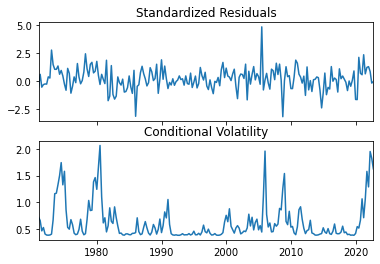

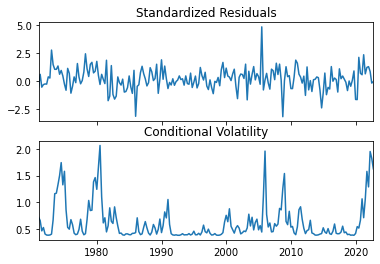

In [24]:
gjr_garch21.plot()

Residual Square VS Conditional Volatility


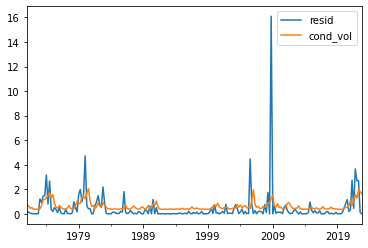

In [26]:
(gjr_garch21.resid**2).plot(legend = "Residuals Square")
gjr_garch21.conditional_volatility.plot(legend = "Conditional Volatiliy")
print('Residual Square VS Conditional Volatility')

$
\pi (t) = c +\rho \pi (t-1)   + \phi fc(t-1) + \epsilon (t)
$

In [27]:
gjr_garch21 = arch_model(y=sample_data['Inflation'],x=sample_data['Forecasted inflation'], mean='ARX', p=2, o=2, q=1,dist='normal',lags=[1]).fit(disp='off',cov_type='robust')
gjr_garch21.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                        AR-X - GJR-GARCH Model Results                        
==============================================================================
Dep. Variable:              Inflation   R-squared:                       0.435
Mean Model:                      AR-X   Adj. R-squared:                  0.429
Vol Model:                  GJR-GARCH   Log-Likelihood:               -170.736
Distribution:                  Normal   AIC:                           359.471
Method:            Maximum Likelihood   BIC:                           389.466
                                        No. Observations:                  207
Date:                Mon, Jun 05 2023   Df Residuals:                      204
Time:                        00:02:36   Df Model:                            3
                                      Mean Model                                     
=====================================================================================
                           coef    std err          t      P>|t|     95.0% Conf. Int.
-------------------------------------------------------------------------------------
Const                    0.0919  8.690e-02      1.057      0.290 [-7.843e-02,  0.262]
Inflation[1]             0.1224      0.112      1.096      0.273 [-9.654e-02,  0.341]
Forecasted inflation     0.8657      0.154      5.617  1.941e-08    [  0.564,  1.168]
                              Volatility Model                             
===========================================================================
                 coef    std err          t      P>|t|     95.0% Conf. Int.
---------------------------------------------------------------------------
omega          0.1406  4.798e-02      2.930  3.386e-03  [4.656e-02,  0.235]
alpha[1]       0.2708      0.169      1.605      0.109 [-5.998e-02,  0.602]
alpha[2]       0.7959      0.397      2.007  4.478e-02  [1.853e-02,  1.573]
gamma[1]      -0.1556      0.181     -0.861      0.389    [ -0.510,  0.199]
gamma[2]      -0.7959      0.377     -2.112  3.469e-02 [ -1.535,-5.728e-02]
beta[1]        0.1094      0.142      0.773      0.440    [ -0.168,  0.387]
===========================================================================

Covariance estimator: robust
"""

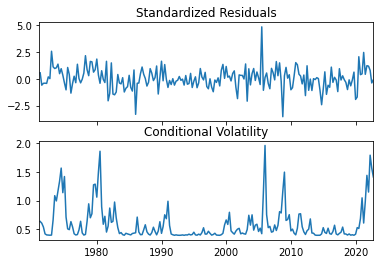

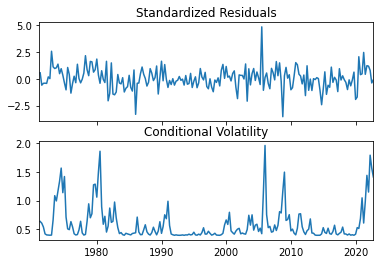

In [28]:
gjr_garch21.plot()

Residual Square VS Conditional Volatility


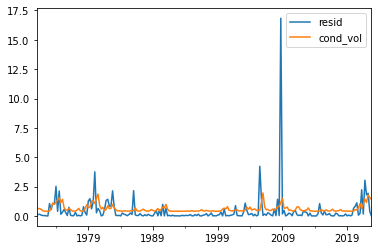

In [29]:
(gjr_garch21.resid**2).plot(legend = "Residuals Square")
gjr_garch21.conditional_volatility.plot(legend = "Conditional Volatiliy")
print('Residual Square VS Conditional Volatility')

$
\pi (t) = c +\rho_1 \pi (t-1)  +\rho_2 \pi (t-2)  + \phi fc(t-1) + \epsilon (t)
$

In [30]:
gjr_garch21 = arch_model(y=sample_data['Inflation'],x=sample_data['Forecasted inflation'], mean='ARX', p=2, o=2, q=1,dist='normal',lags=[1,2]).fit(disp='off',cov_type='robust')
gjr_garch21.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                        AR-X - GJR-GARCH Model Results                        
==============================================================================
Dep. Variable:              Inflation   R-squared:                       0.439
Mean Model:                      AR-X   Adj. R-squared:                  0.431
Vol Model:                  GJR-GARCH   Log-Likelihood:               -170.111
Distribution:                  Normal   AIC:                           360.221
Method:            Maximum Likelihood   BIC:                           393.500
                                        No. Observations:                  206
Date:                Mon, Jun 05 2023   Df Residuals:                      202
Time:                        00:03:40   Df Model:                            4
                                      Mean Model                                     
=====================================================================================
                           coef    std err          t      P>|t|     95.0% Conf. Int.
-------------------------------------------------------------------------------------
Const                    0.0922  9.084e-02      1.015      0.310 [-8.587e-02,  0.270]
Inflation[1]             0.1279      0.124      1.031      0.302    [ -0.115,  0.371]
Inflation[2]             0.0438      0.134      0.327      0.744    [ -0.219,  0.306]
Forecasted inflation     0.8121      0.225      3.602  3.163e-04    [  0.370,  1.254]
                              Volatility Model                             
===========================================================================
                 coef    std err          t      P>|t|     95.0% Conf. Int.
---------------------------------------------------------------------------
omega          0.1382  4.918e-02      2.810  4.948e-03  [4.182e-02,  0.235]
alpha[1]       0.2728      0.173      1.573      0.116 [-6.712e-02,  0.613]
alpha[2]       0.8232      0.415      1.983  4.733e-02  [9.695e-03,  1.637]
gamma[1]      -0.1178      0.240     -0.490      0.624    [ -0.589,  0.353]
gamma[2]      -0.8232      0.392     -2.103  3.550e-02 [ -1.591,-5.585e-02]
beta[1]        0.1007      0.144      0.700      0.484    [ -0.181,  0.383]
===========================================================================

Covariance estimator: robust
"""

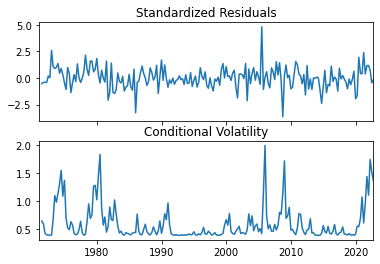

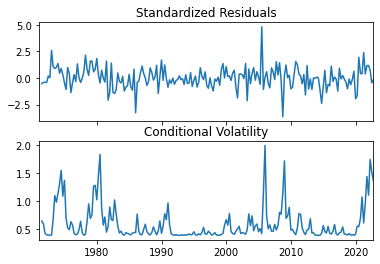

In [32]:
gjr_garch21.plot()

Residual Square VS Conditional Volatility


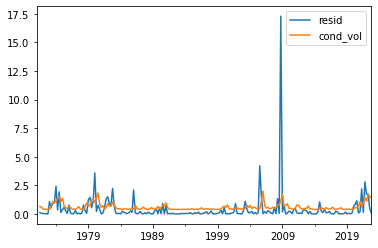

In [31]:
(gjr_garch21.resid**2).plot(legend = "Residuals Square")
gjr_garch21.conditional_volatility.plot(legend = "Conditional Volatiliy")
print('Residual Square VS Conditional Volatility')

$
\pi (t) = c +\rho_1 \pi (t-1)  +\rho_2 \pi (t-2)  + \phi_1 fc(t-1) + \phi_2 fc(t-2) + \epsilon (t)
$

In [35]:
gjr_garch21 = arch_model(y=sample_data['Inflation'],x=sample_data[['Forecasted inflation','Forecasted_inflation_lag_1']], mean='ARX', vol='EGARCH',p=2, o=2, q=1,dist='normal',lags=[1,2]).fit(cov_type='robust')
gjr_garch21.summary()

Iteration:      1,   Func. Count:     13,   Neg. LLF: 2926482794.5975356
Iteration:      2,   Func. Count:     29,   Neg. LLF: 1970266649310.0745
Iteration:      3,   Func. Count:     44,   Neg. LLF: 762537063.6389543
Iteration:      4,   Func. Count:     58,   Neg. LLF: 33727952643.25186
Iteration:      5,   Func. Count:     73,   Neg. LLF: 791538165.6566689
Iteration:      6,   Func. Count:     87,   Neg. LLF: 3389753735.459687
Iteration:      7,   Func. Count:    102,   Neg. LLF: 588761141.4431602
Iteration:      8,   Func. Count:    116,   Neg. LLF: 48744162.88599515
Iteration:      9,   Func. Count:    129,   Neg. LLF: 361.3287198116312
Iteration:     10,   Func. Count:    143,   Neg. LLF: 2558.1287573914865
Iteration:     11,   Func. Count:    157,   Neg. LLF: 2542787.953691214
Iteration:     12,   Func. Count:    170,   Neg. LLF: 1343.009106175718
Iteration:     13,   Func. Count:    183,   Neg. LLF: 171.22236147461513
Iteration:     14,   Func. Count:    195,   Neg. LLF: 170.64

<class 'statsmodels.iolib.summary.Summary'>
"""
                         AR-X - EGARCH Model Results                          
==============================================================================
Dep. Variable:              Inflation   R-squared:                       0.436
Mean Model:                      AR-X   Adj. R-squared:                  0.425
Vol Model:                     EGARCH   Log-Likelihood:               -170.497
Distribution:                  Normal   AIC:                           362.995
Method:            Maximum Likelihood   BIC:                           399.601
                                        No. Observations:                  206
Date:                Mon, Jun 05 2023   Df Residuals:                      201
Time:                        00:06:08   Df Model:                            5
                                          Mean Model                                         
=============================================================================================
                                 coef    std err          t      P>|t|       95.0% Conf. Int.
---------------------------------------------------------------------------------------------
Const                          0.1118  6.540e-02      1.709  8.743e-02   [-1.641e-02,  0.240]
Inflation[1]                   0.2092  2.644e-02      7.912  2.534e-15      [  0.157,  0.261]
Inflation[2]               1.8074e-04  4.964e-02  3.641e-03      0.997 [-9.711e-02,9.747e-02]
Forecasted inflation           0.4816  1.482e-02     32.484 1.797e-231      [  0.453,  0.511]
Forecasted_inflation_lag_1     0.2259  2.694e-02      8.383  5.172e-17      [  0.173,  0.279]
                              Volatility Model                             
===========================================================================
                 coef    std err          t      P>|t|     95.0% Conf. Int.
---------------------------------------------------------------------------
omega         -0.3869      0.153     -2.523  1.163e-02 [ -0.687,-8.636e-02]
alpha[1]       0.4806      0.140      3.441  5.801e-04    [  0.207,  0.754]
alpha[2]      -0.0310      0.205     -0.152      0.879    [ -0.432,  0.370]
gamma[1]       0.0638      0.136      0.469      0.639    [ -0.203,  0.330]
gamma[2]       0.3862      0.137      2.824  4.750e-03    [  0.118,  0.654]
beta[1]        0.6717      0.110      6.103  1.038e-09    [  0.456,  0.887]
===========================================================================

Covariance estimator: robust
"""

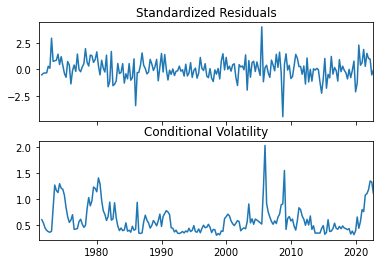

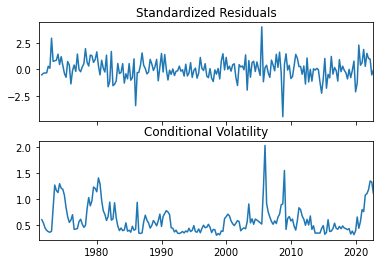

In [37]:
gjr_garch21.plot()

Residual Square VS Conditional Volatility


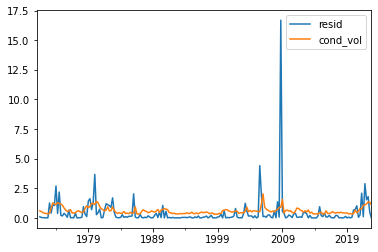

In [36]:
(gjr_garch21.resid**2).plot(legend = "Residuals Square")
gjr_garch21.conditional_volatility.plot(legend = "Conditional Volatiliy")
print('Residual Square VS Conditional Volatility')

In [18]:
from __future__ import annotations
from arch.univariate.distribution import Distribution
from abc import ABCMeta, abstractmethod
from collections.abc import Sequence
from typing import Callable
import warnings

from numpy import (
    abs,    array,    asarray,    empty,    exp,    int64,    
    integer,    isscalar,    log,    nan,    ndarray, exp,
    ones_like,    pi,    sign,    sqrt,    sum,)
from numpy.random import Generator, RandomState, default_rng
from scipy.special import comb, gamma, gammainc, gammaincc, gammaln
import scipy.stats as stats
from scipy.optimize import bisect

from arch.typing import ArrayLike, ArrayLike1D, Float64Array
from arch.utility.array import AbstractDocStringInheritor, ensure1d
class MixNormal(Distribution, metaclass=AbstractDocStringInheritor):
    """
    Mixture of two Normal distributions for use with SPARCH model

    Parameters
    ----------
    random_state : RandomState, optional
        .. deprecated:: 5.0

           random_state is deprecated. Use seed instead.

    seed : {int, Generator, RandomState}, optional
        Random number generator instance or int to use. Set to ensure
        reproducibility. If using an int, the argument is passed to
        ``np.random.default_rng``.  If not provided, ``default_rng``
        is used with system-provided entropy.
    """

    def __init__(
        self,
        random_state: RandomState | None = None,
        *,
        seed: None | int | RandomState | Generator = None,
    ) -> None:
        super().__init__(random_state=random_state, seed=seed)
        self._name = "Mixture of two Normal distributions"
        self.num_params: int = 3  

    def constraints(self) -> tuple[Float64Array, Float64Array]:
        return array([[1, 0, 0], [-1, 0, 0], [0, 1,0], [0, -1,0] , [0,0,1],[0,0,-1]]), array([0, 1, -100,100,0.001, 10000])

    def bounds(self, resids: Float64Array) -> list[tuple[float, float]]:
        """
        Bounds of parameters:
        p1: (0,1)
        u1: (-100,100)
        sigma1:(0.0001*var(resids),1000*var(resids))
        """
        return [(0, 1),(-100,100),(0.001, 10000)]

    def loglikelihood(
        self,
        parameters: Sequence[float] | ArrayLike1D,
        resids: ArrayLike,
        sigma2: ArrayLike,
        individual: bool = False,
    ) -> float | Float64Array:
        r"""Computes the log-likelihood of assuming residuals are mixture normally
        distributed, conditional on the variance

        Parameters
        ----------
        parameters : ndarray
            Parameters of the first normal distribution: p1,u1,sigma1. Second one can be calculated by restrictions.
        resids  : ndarray
            The residuals to use in the log-likelihood calculation
        sigma2 : ndarray
            Conditional variances of resids
        individual : bool, optional
            Flag indicating whether to return the vector of individual log
            likelihoods (True) or the sum (False)

        Returns
        -------
        ll : float
            The log-likelihood

        Notes
        -----
        The log-likelihood of a single data point x is

        .. math::

            \ln f\left(x\right)=
            \ln \frac{1}{\sqrt{h_t}} \left[
                 p_1  \frac{1}{\sqrt{ 2\pi\sigma_1^2} } exp\{ -\frac{(x-\mu_1)^2}{2\sigma_1^2} \}
                +(1-p_1)\frac{1}{\sqrt{ 2\pi\sigma_2^2} } exp\{ -\frac{(x-\mu_2)^2}{2\sigma_2^2} \} \right]

        """
        parameters = asarray(parameters, dtype=float)
        p1, u1, sigma_1 = parameters
        
        p2 = 1- p1
        u2 = p1/(p1-1) *u1
        sigma_2 = sqrt(p1/(p1-1)*sigma_1**2 - p1/(p1-1)**2 * u1**2 + 1/(1-p1))
        
        lls = log( 1/sqrt(sigma2) * ( p1/sqrt(2*pi*sigma_1**2) *  exp(-(resids/sqrt(sigma2)-u1)**2/(2*sigma_1**2))   +   p2/sqrt(2*pi*sigma_2**2) *  exp(-(resids/sqrt(sigma2)-u2)**2/(2*sigma_2**2))        )     ) 
        if individual:
            return lls
        else:
            return sum(lls)

    def starting_values(self, std_resid: Float64Array) -> Float64Array:
        """
        Starting values of parameters
        """
        p90 = np.percentile(std_resid, 90)
        m = np.mean(std_resid[std_resid<=p90])
        sd =  np.std(std_resid[std_resid<=p90])
        return array([0.8 , m, sd])

    def _simulator(self, size: int | tuple[int, ...]) -> Float64Array:
        return self._generator.standard_normal(size)

    def simulate(
        self, parameters: int | float | Sequence[float | int] | ArrayLike1D
    ) -> Callable[[int | tuple[int, ...]], Float64Array]:
        return self._simulator

    def parameter_names(self) -> list[str]:
        return ['p_1','mu_1','sigma_1']

    def cdf(
        self,
        resids: Sequence[float] | ArrayLike1D,
        parameters: None | Sequence[float] | ArrayLike1D = None,
    ) -> Float64Array:
        self._check_constraints(parameters)
        
        parameters = asarray(parameters, dtype=float)
        p1, u1, sigma_1 = parameters
        p2 = 1- p1
        u2 = p1/(p1-1) *u1
        sigma_2 = sqrt(p1/(p1-1)*sigma_1**2 - p1/(p1-1)**2 * u1**2 + 1/(1-p1))
        
        return p1*stats.norm.cdf(asarray((resids-u1)/sigma_1)  ) + p2*stats.norm.cdf(asarray((resids-u2)/sigma_2)  )

    def ppf(
        self,
        pits: float | Sequence[float] | ArrayLike1D,
        parameters: None | Sequence[float] | ArrayLike1D = None,
    ) -> Float64Array:
        self._check_constraints(parameters)
        parameters = asarray(parameters, dtype=float)
        p1, u1, sigma_1 = parameters
        p2 = 1- p1
        u2 = p1/(p1-1) *u1
        sigma_2 = sqrt(p1/(p1-1)*sigma_1**2 - p1/(p1-1)**2 * u1**2 + 1/(1-p1)) 
        scalar = isscalar(pits)
        if scalar:
            pits = array([pits])
        else:
            pits = asarray(pits)
            
        def inverse_cdf(cdf, target_p, lower_bound=-100, upper_bound=100):
            def root_func(x):
                return cdf(x,parameters) - target_p
            return bisect(root_func, lower_bound, upper_bound)     
        
        ppf = inverse_cdf(cdf, pits, lower_bound=-100, upper_bound=100)

        if scalar:
            return ppf[0]
        else:
            return ppf
        
   

    def moment(
        self, n: int, parameters: None | Sequence[float] | ArrayLike1D = None
    ) -> float:
        if n < 0:
            return nan
        parameters = asarray(parameters, dtype=float)
        p1, u1, sigma2_1 = parameters
        p2 = 1- p1
        u2 = p1/(p1-1) *u1
        sigma2_2 = p1/(p1-1)*sigma2_1 - p1/(p1-1)**2 * u1**2 + 1/(1-p1) 
        
        moment1 = u1 ** n + sigma2_1 * n * (u1 ** (n - 2)) if n >= 2 else u1 ** n
        moment2 = u2 ** n + sigma2_2 * n * (u2 ** (n - 2)) if n >= 2 else u2 ** n
        return p1 * moment1 + p2 * moment2

    def partial_moment(
        self,
        n: int,
        z: float = 0.0,
        parameters: None | Sequence[float] | ArrayLike1D = None,
        num_samples=100000,
    ) -> float:
        
        parameters = asarray(parameters, dtype=float)
        p1, u1, sigma2_1 = parameters
        p2 = 1- p1
        u2 = p1/(p1-1) *u1
        sigma2_2 = p1/(p1-1)*sigma2_1 - p1/(p1-1)**2 * u1**2 + 1/(1-p1) 
        
        if n < 0:
            return nan
        elif n == 0:
            return cdf(z,parameters)
        else:
            num_samples=100000
            samples1 = np.random.normal(u1, sigma2_1**0.5, int(num_samples * p1))
            samples2 = np.random.normal(u2, sigma2_2**0.5, int(num_samples * p2))
            samples = np.concatenate((samples1, samples2))
            samples = samples[samples <= z]
            return np.mean((z - samples) ** n)